# Week 2 — Cross-Validation and Ridge on NHANES

*INFO 521 worked notebook (Module 2). Companion to lectures m2a/m2b. Needs the course
environment (`info521` package).*

Training error always falls as a model gets more flexible — so it cannot choose the model.
Here we run **k-fold cross-validation** over polynomial degree, then control complexity
continuously with **ridge** and tune $\lambda$ by CV. All from scratch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from info521.data import load_clinical, primary_predictor

BLUE, VERMILLION, GREEN = "#0072B2", "#D55E00", "#009E73"
rng = np.random.default_rng(521)

ds  = load_clinical()
age = primary_predictor(ds); sbp = ds["y"]
z   = (age - age.mean()) / age.std()

# Illustrative teaching signal on the REAL age grid (real SBP–age is near-linear,
# so it can't show underfitting; lecture m2a makes the same move, clearly labeled).
def true_g(t): return 120.0 + 2.0*t + 15.0*np.sin(1.3*t)
y_ill = true_g(z) + rng.normal(0, 9.0, size=len(z))

def mse(a, b): return float(np.mean((a - b) ** 2))
def poly_design(t, deg): return np.column_stack([t**k for k in range(deg + 1)])

## Train vs. test across complexity

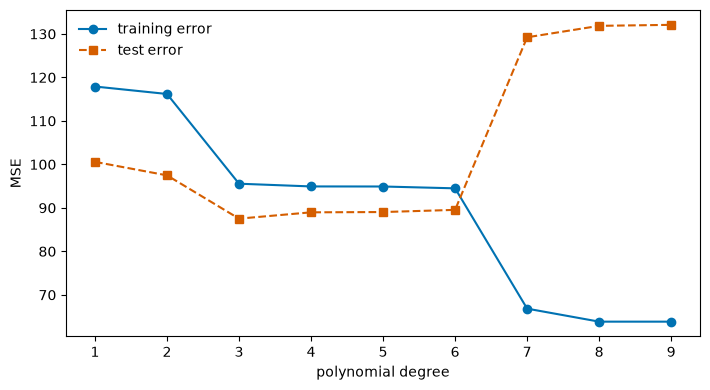

In [2]:
perm = rng.permutation(len(z))
tr, te = perm[:45], perm[45:445]          # small train set → overfitting shows
degs = range(1, 10)
train_err, test_err = [], []
for d in degs:
    c = np.polyfit(z[tr], y_ill[tr], d)
    train_err.append(mse(y_ill[tr], np.polyval(c, z[tr])))
    test_err.append(mse(y_ill[te], np.polyval(c, z[te])))

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(list(degs), train_err, "o-",  color=BLUE,       label="training error")
ax.plot(list(degs), test_err,  "s--", color=VERMILLION, label="test error")
ax.set_xlabel("polynomial degree"); ax.set_ylabel("MSE")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Training error only falls; test error is **U-shaped**. The gap between them is the
generalization gap.

## k-fold cross-validation, from scratch

Every patient validates exactly once and trains $k{-}1$ times. **Preprocess inside the
fold** — here the polynomial features are built per-split, so nothing leaks.

In [3]:
n_cv  = 150
ci    = rng.permutation(len(z))[:n_cv]
zc, yc = z[ci], y_ill[ci]
k     = 5
folds = np.array_split(np.arange(n_cv), k)

cv_mean = []
for d in degs:
    errs = []
    for f in range(k):
        val = folds[f]
        trn = np.concatenate([folds[j] for j in range(k) if j != f])
        c = np.polyfit(zc[trn], yc[trn], d)
        errs.append(mse(yc[val], np.polyval(c, zc[val])))
    cv_mean.append(np.mean(errs))
best_deg = list(degs)[int(np.argmin(cv_mean))]
print("CV chooses degree", best_deg)

CV chooses degree 3


## Ridge: complexity as a dial

Ridge adds $\lambda\lVert\mathbf{w}\rVert_2^2$ to the loss; the closed form just adds
$\lambda\mathbf{I}$ inside the normal equations. The intercept is **not** penalized —
we center $y$ and standardize the feature columns instead (lecture m2b).

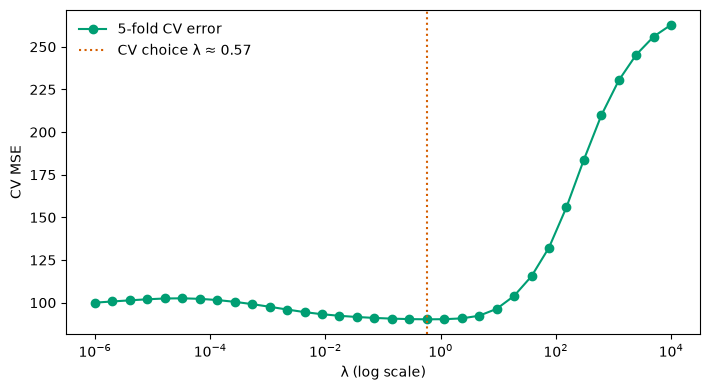

In [4]:
def poly_std(t, deg, mu=None, sd=None):
    F = np.column_stack([t**k for k in range(1, deg + 1)])
    if mu is None: mu, sd = F.mean(0), F.std(0)
    return (F - mu) / sd, mu, sd

def ridge_fit(Phi, y, lam):
    D = Phi.shape[1]
    w = np.linalg.solve(Phi.T @ Phi + lam*np.eye(D), Phi.T @ (y - y.mean()))
    return w, float(y.mean())

deg  = 14
lams = np.logspace(-6, 4, 34)
cv   = []
for lam in lams:
    errs = []
    for f in range(k):
        val = folds[f]
        trn = np.concatenate([folds[j] for j in range(k) if j != f])
        Phi_tr, mu, sd = poly_std(zc[trn], deg)            # standardize on TRAIN only
        w, b = ridge_fit(Phi_tr, yc[trn], lam)
        Phi_val = (np.column_stack([zc[val]**k for k in range(1, deg+1)]) - mu) / sd
        errs.append(mse(yc[val], Phi_val @ w + b))
    cv.append(np.mean(errs))
best_lam = lams[int(np.argmin(cv))]

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(lams, cv, "o-", color=GREEN, label="5-fold CV error")
ax.axvline(best_lam, color=VERMILLION, linestyle=":",
           label=f"CV choice λ ≈ {best_lam:.2g}")
ax.set_xscale("log"); ax.set_xlabel("λ (log scale)"); ax.set_ylabel("CV MSE")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Both ends of the λ axis are degenerate — λ→0 recovers the overfit OLS, λ→∞ predicts a
constant. CV finds the middle.

**Try it yourself:** re-run the ridge CV with the standardization computed on the *pooled*
data (the classic leak). How much rosier does the CV curve look? That gap is why the
leakage rule exists.